In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [3]:
file_path = '/content/drive/MyDrive/Datasets/gold_data.csv'
gold_data = pd.read_csv(file_path)

In [4]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
gold_data.shape

(2290, 6)

In [6]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


EUR/USD = Currency Pair

In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


Correlation:
1. +ve correlation
2. -ve Correlation

In [15]:
gold_data = gold_data.drop('Date', axis=1)

In [16]:
correlation = gold_data.corr()

<Axes: >

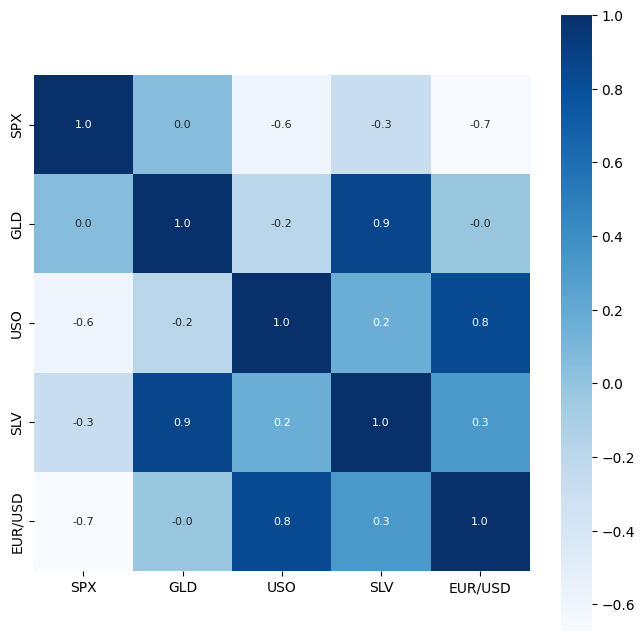

In [18]:
# constructing heatmap to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [19]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_1371/1730314454.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='Green')


<Axes: xlabel='GLD', ylabel='Density'>

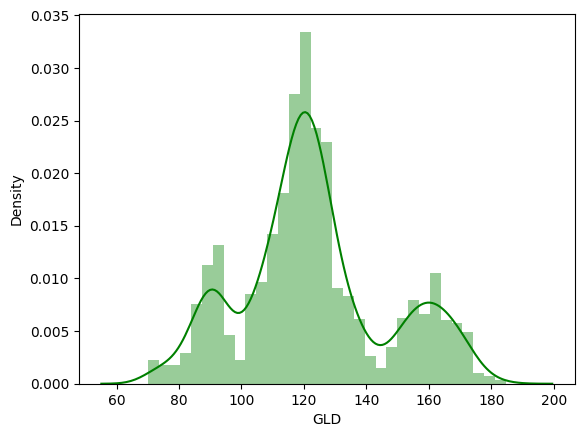

In [21]:
# check the distribution of the gold price
sns.distplot(gold_data['GLD'], color='Green')

In [23]:
X = gold_data.drop('GLD', axis=1)
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [25]:
Y = gold_data['GLD']
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [28]:
regressor = RandomForestRegressor(n_estimators=100)

In [29]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [30]:
# Model Evaluation
# prediction on test data
test_data_prediction = regressor.predict(X_test)

In [31]:
print(test_data_prediction)

[168.49599917  82.12169977 116.15240027 127.7448009  120.4960012
 154.69889782 150.31959853 126.2528003  117.39899876 126.03440059
 116.72580104 171.12440077 141.59829853 167.72419868 115.21160023
 117.15150054 138.34370317 170.35850116 159.37850244 157.45349952
 155.14480047 125.06399967 175.8548004  157.97540391 125.30500034
  93.84569964  77.8013997  120.48750006 119.19759985 167.46240032
  88.04480006 125.14740006  91.09190091 117.69949991 121.0534994
 136.40670047 115.43340107 115.3779007  146.77099913 107.34490067
 104.77810269  87.16849812 126.49260036 118.0844001  154.11019913
 119.67710012 108.3616003  108.14849856  93.14380035 127.24649723
  74.53190051 113.62049951 121.06010004 111.18709932 118.95609895
 120.67379955 158.89910175 169.18690152 146.99129667  85.70199847
  94.15970062  86.69949866  90.49330046 118.9353009  126.41220046
 127.47499988 168.68240033 122.15769951 117.28419891  98.56670024
 167.98620091 142.88379796 132.54440195 121.18300169 121.23199925
 119.7447006

In [32]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print(error_score)

0.9897282227957334


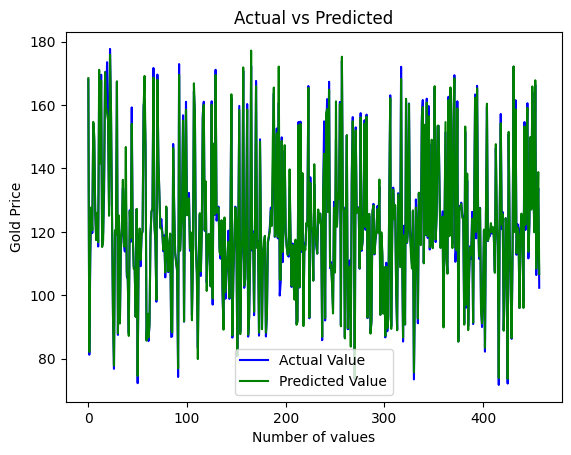

In [35]:
# Compare actual and predicted values in matplot
Y_test = list(Y_test)
plt.plot(Y_test, color='blue', label='Actual Value')
plt.plot(test_data_prediction, color='green', label="Predicted Value")
plt.title('Actual vs Predicted')
plt.xlabel('Number of values')
plt.ylabel("Gold Price")
plt.legend()
plt.show()